# Personalized Agent — Extract, Store, Retrieve, Ingest

The full long-term memory pipeline, as one LangGraph graph:

1. **Creation** — `extract_memory_node` asks the LLM (via structured
   output) whether the latest message contains a fact/preference worth
   remembering.
2. **Storage** — if so, it's written into the `store` under this
   user's namespace.
3. **Retrieval** — `respond_node` searches that namespace for anything
   stored so far.
4. **Ingestion** — whatever's retrieved is folded into a system message
   before the model replies, so the reply is personalized to what the
   user has told it in the past — even on a BRAND NEW thread, since
   this lives in the long-term store, not the thread-scoped
   checkpointer.


In [1]:
from typing import Annotated, Optional, TypedDict

from dotenv import load_dotenv
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.store.base import BaseStore
from langgraph.store.memory import InMemoryStore
from pydantic import BaseModel

load_dotenv()

model = ChatGroq(model="llama-3.1-8b-instant")

/Users/apekshagangurde/Desktop/Langchain models/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Creation — extract a memory-worthy fact with structured output


In [2]:
class MemoryExtraction(BaseModel):
    has_memory: bool
    memory: Optional[str] = None


extractor = model.with_structured_output(MemoryExtraction)

In [3]:
class ChatState(TypedDict):
    user_id: str
    # short-term memory: this thread's running history (checkpointer-backed)
    messages: Annotated[list[BaseMessage], add_messages]

In [4]:
def extract_memory_node(state: ChatState, *, store: BaseStore) -> ChatState:
    last_message = state["messages"][-1]

    extraction = extractor.invoke(
        "Extract any fact or preference worth remembering long-term about "
        "the user from this message. If nothing is worth remembering, set "
        f"has_memory to false.\n\nMessage: {last_message.content}"
    )

    if extraction.has_memory and extraction.memory:
        namespace = (state["user_id"], "memories")
        key = extraction.memory.lower().replace(" ", "_")[:40]
        store.put(namespace, key, {"text": extraction.memory})

    return {}

## Retrieval + ingestion — personalize the reply


In [5]:
def respond_node(state: ChatState, *, store: BaseStore) -> ChatState:
    namespace = (state["user_id"], "memories")
    memories = store.search(namespace)

    if memories:
        memory_text = "\n".join(f"- {m.value['text']}" for m in memories)
        system = SystemMessage(
            content=(
                f"Known long-term facts/preferences about this user:\n{memory_text}\n\n"
                "Use them to personalize your reply where relevant."
            )
        )
        final_messages = [system] + state["messages"]
    else:
        final_messages = state["messages"]

    response = model.invoke(final_messages)
    return {"messages": [response]}

In [6]:
graph = StateGraph(ChatState)

graph.add_node("extract_memory", extract_memory_node)
graph.add_node("respond", respond_node)

graph.add_edge(START, "extract_memory")
graph.add_edge("extract_memory", "respond")
graph.add_edge("respond", END)

# checkpointer -> short-term (thread-scoped) memory
# store        -> long-term (cross-thread) memory
checkpointer = MemorySaver()
store = InMemoryStore()

workflow = graph.compile(checkpointer=checkpointer, store=store)

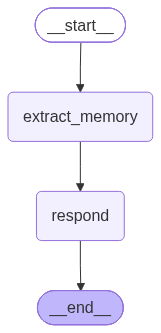

In [7]:
# print/visualize the graph
from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png()))

## Turn 1 — teach it a preference (thread-1)


In [ ]:
config_thread_1 = {"configurable": {"thread_id": "thread-1"}}

result = workflow.invoke(
    {
        "user_id": "user_1",
        "messages": [
            HumanMessage(content="I really prefer replies in Hindi, not English.")
        ],
    },
    config=config_thread_1,
)
print(result["messages"][-1].content)

मैं आपके साथ हिंदी में बातचीत करने के लिए तैयार हूँ। आप अपने कोई सवाल या विषय के बारे में बता सकते हैं और मैं आपकी सहायता करने की कोशिश करूँगा।


## Turn 2 — a BRAND NEW thread, same user

`thread-2` has no message history at all in the checkpointer, so this
is a fresh conversation as far as short-term memory is concerned. The
Hindi preference still shows up in the reply because it came from the
long-term `store`, keyed by `user_id`, not by thread.


In [9]:
config_thread_2 = {"configurable": {"thread_id": "thread-2"}}

result = workflow.invoke(
    {
        "user_id": "user_1",
        "messages": [HumanMessage(content="Tell me something about the Eiffel Tower.")],
    },
    config=config_thread_2,
)
print(result["messages"][-1].content)

मैं आपको ईफेल टावर के बारे में कुछ जानकारी देने की कोशिश करूँगा। ईफेल टावर पेरिस का एक प्रसिद्ध स्थल है, जिसे यूरोप के सबसे ऊंचे मैन मेड स्ट्रक्चर के रूप में जाना जाता है। 

ईफेल टावर का निर्माण फ्रांस के गगनचुंबी इमारत के वास्तुकार गुस्ताव ईफेल द्वारा किया गया था। यह 1889 में विश्व प्रदर्शनी के लिए बनाया गया था, जिसे विश्व के इतिहास में सबसे बड़े प्रदर्शनी के संग्रह के रूप में जाना जाता है। 

ईफेल टावर की ऊंचाई 324 मीटर है, और इसका निर्माण 2.5 वर्ष में पूरा हुआ था। यह पेरिस के चारों ओर विस्तारित एक विशाल शहर दिखाता है। इसकी देखभाल करने वाली कंपनी टूरिस्ट फ्रेंच के अनुसार, यह स्थल हर साल 7 मिलियन से अधिक पर्यटकों को आकर्षित करता है।

ईफेल टावर दुनिया की सबसे ऊंची संरचनाओं में से एक है और यह एक प्रसिद्ध प्रतीक भी है। यह पेरिस का एक प्रमुख आकर्षण है और यह दुनिया भर के पर्यटकों के लिए एक मुख्य गंतव्य स्थल है।


## What's actually stored in long-term memory


In [10]:
for item in store.search(("user_1", "memories")):
    print(item.key, "->", item.value)

hindi_preferred_language -> {'text': 'Hindi preferred language'}
